In [1]:
import SimpleITK as sitk
import numpy as np
import sigpy
sitk_t1 = sitk.ReadImage('t1.nii.gz')
t1 = sitk.GetArrayFromImage(sitk_t1)

c:\Users\Ines\anaconda3\envs\3d-mri\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(256, 256)


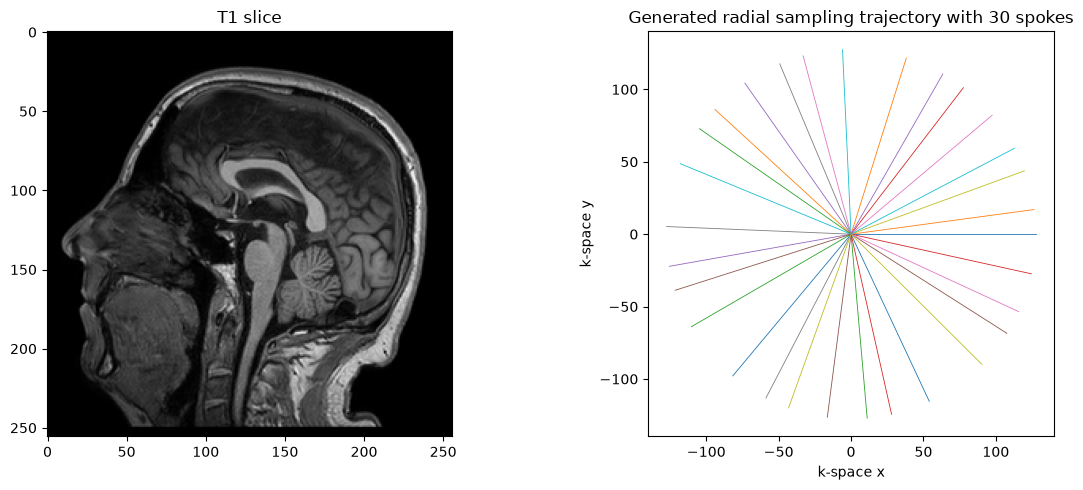

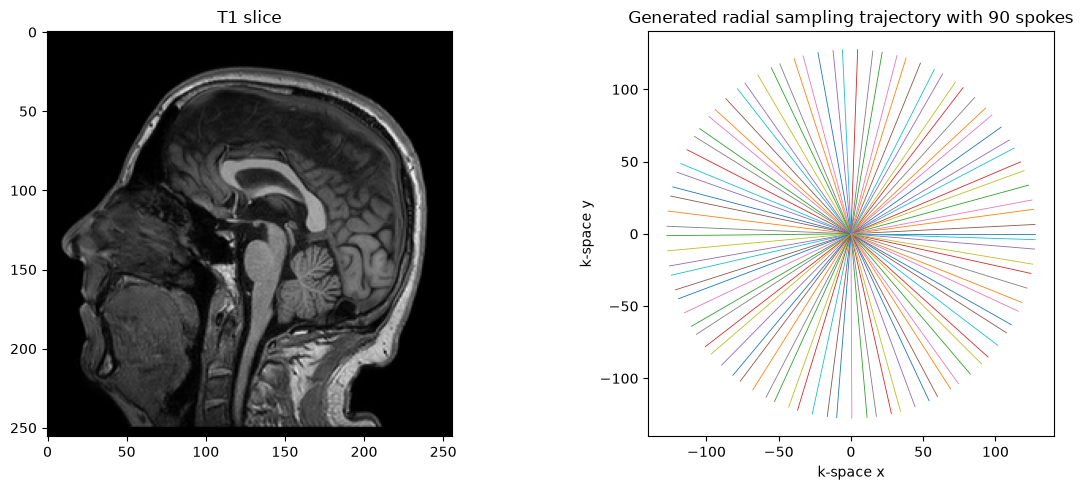

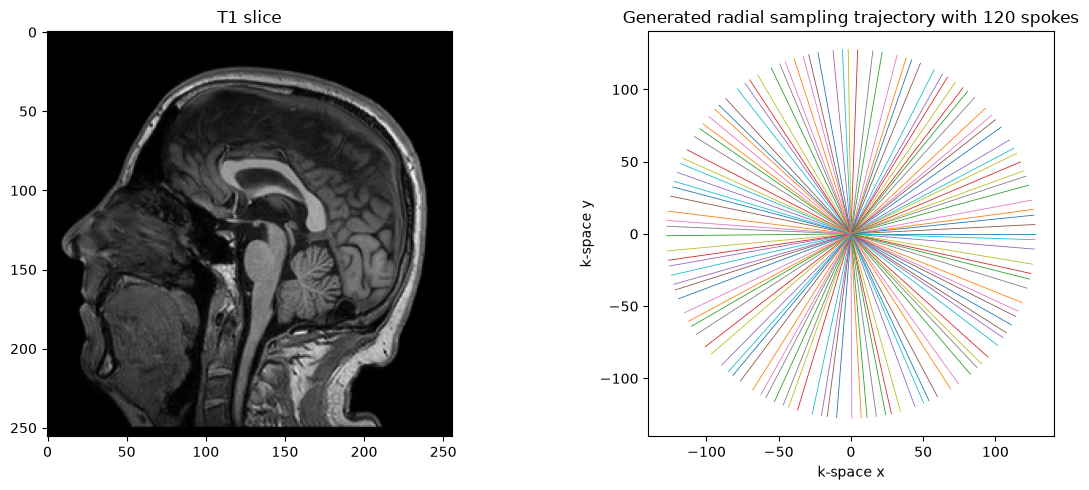

In [4]:
""" TODO TASK 4:sigpy.mri.app.L1WaveletRecon is designed to perform compressed sensing
reconstruction. Try that method with radial sampling for different number of spokes. Do the
same with sigpy.mri.app.TotalVariationRecon. Play around with the parameters of
these methods and discuss their influence on the reconstruction in the report. Notice that
these methods can also use different coils, but we are working with only one. Set the
appropriate sensitivity map to disregard that. """
from sigpy.mri import samp
import matplotlib.pyplot as plt
slice=t1[45,:,:]
print(slice.shape)
num_spokes = 30,90,120
for n in num_spokes:
    radial_sampling = samp.radial((n, slice.shape[0], 2), slice.shape)
    fig, (ax_img, ax_traj) = plt.subplots(1, 2, figsize=(12, 5))

    ax_img.imshow(slice, cmap="gray")
    ax_img.set_title("T1 slice")

    for spoke in radial_sampling:
        ax_traj.plot(spoke[:, 1], spoke[:, 0], linewidth=0.6)

    ax_traj.set_aspect("equal")
    ax_traj.set_title(f"Generated radial sampling trajectory with {n} spokes")
    ax_traj.set_xlabel("k-space x")
    ax_traj.set_ylabel("k-space y")

    plt.tight_layout()
    plt.show()



L1WaveletRecon: 100%|██████████| 200/200 [00:02<00:00, 93.63it/s, resid=2.77E+02] 


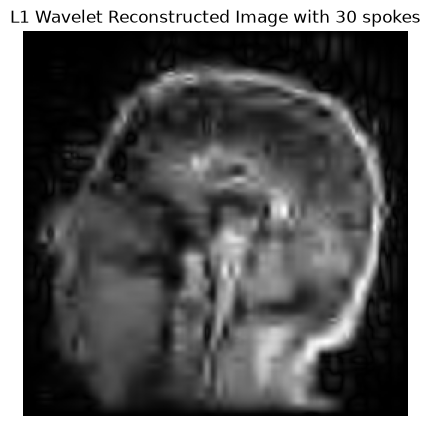

L1WaveletRecon: 100%|██████████| 200/200 [00:03<00:00, 50.83it/s, resid=5.75E+02]


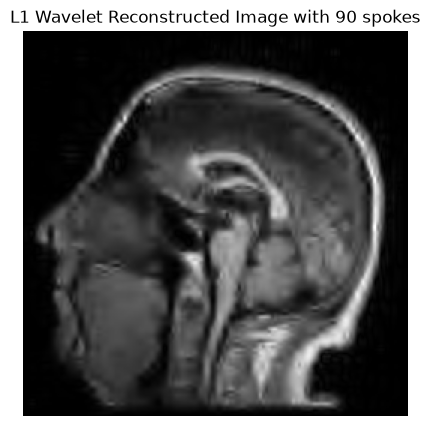

L1WaveletRecon: 100%|██████████| 200/200 [00:04<00:00, 40.60it/s, resid=8.27E+02]


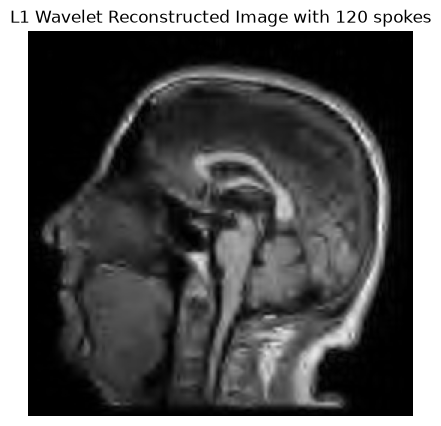

In [4]:
from sigpy.mri.app import L1WaveletRecon
image = slice.astype(np.complex64)
mps = np.ones((1, *image.shape), dtype=np.complex64)
reconstructed_images = []
for n in num_spokes:
    radial_sampling = samp.radial((n, image.shape[0], 2), image.shape)
    y = sigpy.nufft(image, radial_sampling)[None, ...]
    l1_wavelet_recon = L1WaveletRecon(
        y,
        mps,
        lamda=100,
        coord=radial_sampling,
    max_iter=200,
    )
    reconstructed_image = l1_wavelet_recon.run()
    plt.figure(figsize=(6, 5))
    plt.imshow(np.abs(reconstructed_image), cmap="gray")
    plt.title(f"L1 Wavelet Reconstructed Image with {n} spokes")
    plt.axis("off")
    plt.show()




TotalVariationRecon: 100%|██████████| 200/200 [00:01<00:00, 105.72it/s, resid=3.05E+01]


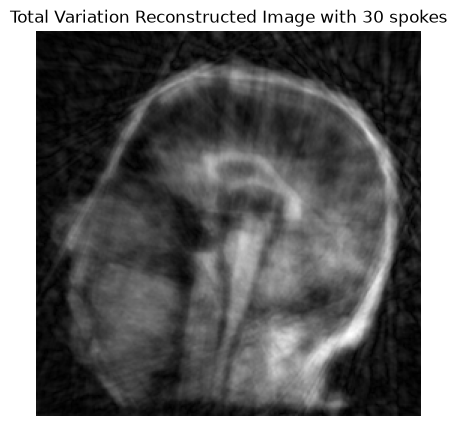

TotalVariationRecon: 100%|██████████| 200/200 [00:03<00:00, 50.68it/s, resid=1.30E+02]


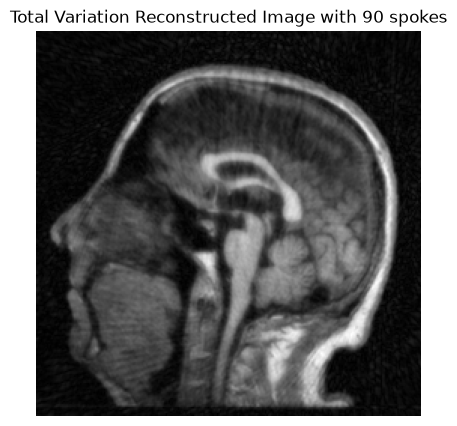

TotalVariationRecon: 100%|██████████| 200/200 [00:05<00:00, 39.69it/s, resid=1.86E+02]


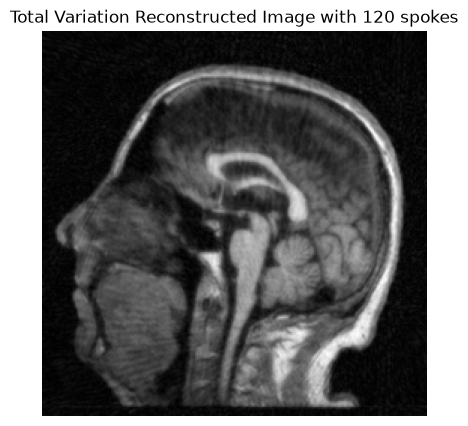

In [5]:
from sigpy.mri.app import TotalVariationRecon
for n in num_spokes:
    radial_sampling = samp.radial((n, image.shape[0], 2), image.shape)
    y = sigpy.nufft(image, radial_sampling)[None, ...]
    tv_recon = TotalVariationRecon(
        y,
        mps,
        lamda=0.0001,
        coord=radial_sampling,
    max_iter=200,
    )
    reconstructed_image_tv = tv_recon.run()
    plt.figure(figsize=(6, 5))
    plt.imshow(np.abs(reconstructed_image_tv), cmap="gray")
    plt.title(f"Total Variation Reconstructed Image with {n} spokes")
    plt.axis("off")
    plt.show()

In [6]:
""" OBSERVATIONS

L1 Wavelet Reconstructed Image : 
1)lamda: The regularization parameter controls the trade-off between data fidelity 
and sparsity. A higher value of lambda will result in a sparser solution, which can lead to loss of detail in the image. 
A lower value of lambda will result in a less sparse solution, which can lead to more noise in the image.
2)num_spokes: The number of spokes in the radial sampling pattern affects the amount of data that is collected.
A higher number of spokes will result in more data being collected, which can lead to a better reconstruction. A lower 
number of spokes will result in less data being collected, which can lead to a worse reconstruction.
3)max_iter: The maximum number of iterations controls how long the algorithm will run. A higher value of max_iter will result in a better reconstruction, 
but will take longer to run. A lower value of max_iter will result in a worse reconstruction, but will take less time to run."""


""" Total Variation Reconstructed Image :
1)lamda: The regularization parameter controls the trade-off between data fidelity and smoothness. A higher value of lambda will result in a smoother solution, 
which can lead to loss of detail and texture in the image. A lower value of lambda will result in a less smooth solution, which can lead to more noise in the 
image.
2)num_spokes: The number of spokes in the radial sampling pattern affects the amount of data that is collected. A higher number of 
spokes will result in more data being collected and can lead to a better reconstruction. A lower number of spokes will result in 
less data being collected, which can lead to a worse reconstruction.
3)max_iter: The maximum number of iterations controls how long the algorithm will run. A higher value of max_iter will result 
in a better reconstruction, but will take longer to run. A lower value of max_iter will result in a worse reconstruction, but will take less time to run."""

' Total Variation Reconstructed Image :\n1)lamda: The regularization parameter controls the trade-off between data fidelity and smoothness. A higher value of lambda will result in a smoother solution, \nwhich can lead to loss of detail and texture in the image. A lower value of lambda will result in a less smooth solution, which can lead to more noise in the \nimage.\n2)num_spokes: The number of spokes in the radial sampling pattern affects the amount of data that is collected. A higher number of \nspokes will result in more data being collected and can lead to a better reconstruction. A lower number of spokes will result in \nless data being collected, which can lead to a worse reconstruction.\n3)max_iter: The maximum number of iterations controls how long the algorithm will run. A higher value of max_iter will result \nin a better reconstruction, but will take longer to run. A lower value of max_iter will result in a worse reconstruction, but will take less time to run.'

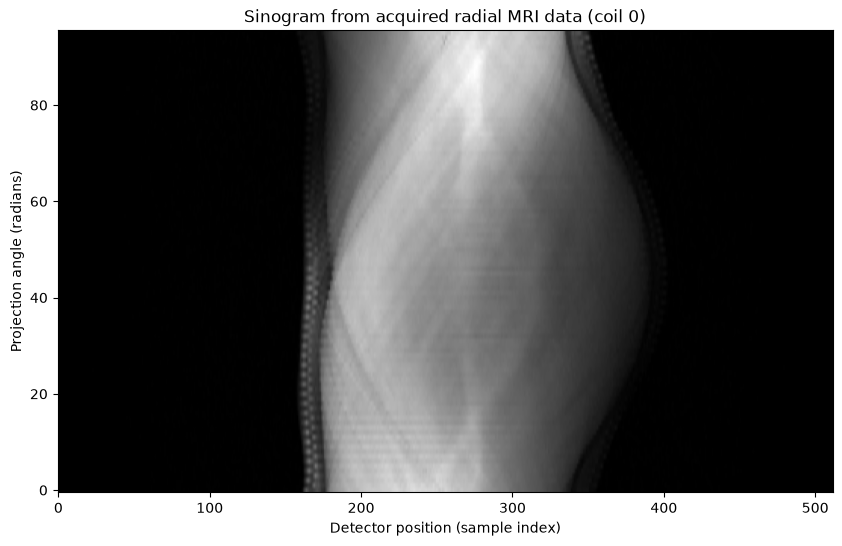

In [ ]:
""" TODO: TASK 5: CT reconstruction methods for radial MRI: (15%)
In class, we briefly mentioned that radial sampling is related to CT reconstruction. This means
all CT reconstruction methods can be applied to MR images. Describe the problem with
equations to model it as a CT reconstruction one, that is, how to set up radial sampling in
terms of a sinogram. WARNING! You need to get the sinogram DIRECTLY from the acquired
data. It is not valid to go to the spatial domain using the methods from points 3 and 4 and
then apply the Radon transform to obtain the sinogram. This is because you will
unnecessarily add all the issues of MRI reconstruction to those of CT reconstruction """
# Use the supplied acquired data directly; do not simulate it from the image.
coord = np.load("projection_coord.npy").astype(np.float32)
acquired_ksp = np.load("projection_ksp.npy").astype(np.complex64)
coil_index = 0
kspace_data = acquired_ksp[coil_index]
n_spokes, n_samples = kspace_data.shape

sinogram_complex = np.empty_like(kspace_data)
angles = np.empty(n_spokes, dtype=np.float32)
for i in range(n_spokes):
    # Get the coordinates of the current spoke in k-space
    ky, kx = coord[i, :, 0], coord[i, :, 1]

    # find the farthest point from the origin in k-space to determine the angle of the spoke
    outer = np.argmax(np.hypot(kx, ky))

    #find the angle of the spoke using the arctangent of the y and x coordinates of the farthest point
    theta = np.arctan2(ky[outer], kx[outer]) % np.pi

    angles[i] = theta

    # calculate the signed distance of each point in the spoke from the origin along the direction of the spoke using the dot product 
    # of the k-space coordinates and the unit vector in the direction of the spoke
    kr = kx * np.cos(theta) + ky * np.sin(theta)

    # sort the points in the spoke by their signed distance from the origin to ensure that they are in the correct order for the inverse Fourier transform
    order = np.argsort(kr)

    #create a new array with the points in the spoke sorted by their signed distance from the origin
    centered_spoke = kspace_data[i, order]

    # perform an inverse 1D Fourier transform on the sorted spoke to obtain the corresponding projection in the sinogram.
    # by central slice 
    sinogram_complex[i] = np.fft.fftshift(
        np.fft.ifft(np.fft.ifftshift(centered_spoke))
    )

angle_order = np.argsort(angles)
angles = angles[angle_order]
sinogram_complex = sinogram_complex[angle_order]
sinogram = np.abs(sinogram_complex)

plt.figure(figsize=(10, 6))
plt.imshow(sinogram, cmap="gray", aspect="auto", origin="lower")
plt.xlabel("Detector position (sample index)")
plt.ylabel("Projection angle (radians)")
plt.title(f"Sinogram from acquired radial MRI data (coil {coil_index})")
plt.show()









sinogram: (96, 512)
angles: (96,)
2.3841858e-07 3.1088676


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

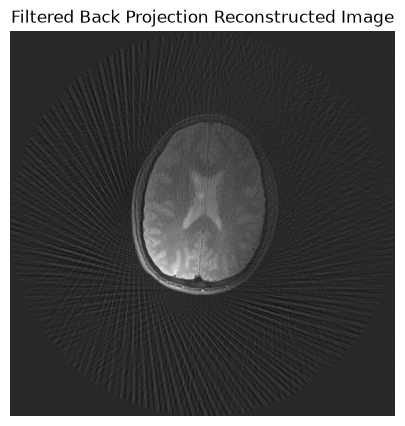

In [ ]:
""" TODO: Run filtered back projection (FBP) to reconstruct the images. Hint: scikit-image implementsFBP and other CT reconstruction methods. """
from skimage.transform import iradon
print("sinogram:", sinogram.shape)
print("angles:", np.shape(angles))
angles_deg = np.rad2deg(angles)
reconstructed_image_fbp = iradon(sinogram.T, theta=angles_deg, filter_name='ramp')
plt.figure(figsize=(6, 5))
plt.imshow(reconstructed_image_fbp, cmap="gray")
plt.title("Filtered Back Projection Reconstructed Image")
plt.axis("off")




In [24]:
import numpy as np
import sigpy
from sigpy.mri import samp
from sigpy.mri.app import L1WaveletRecon, TotalVariationRecon
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

# t1 was loaded earlier in the notebook.
# These are the lambda values used in your reconstruction cells.
lam_l1 = 100
lam_tv = 0.0001
slices = [30, 45, 60]

for R in (5, 10):
    slice_shape = t1.shape[1:]
    # Approximate Nyquist spoke count divided by the acceleration factor.
    num_spokes = max(1, round(np.pi * slice_shape[0] / (2 * R)))
    coord = samp.radial((num_spokes, slice_shape[0], 2), slice_shape)

    scores = {"L1-wavelet": [], "TV": [], "NUFFT-adjoint baseline": []}

    for z in slices:
        img = t1[z].astype(np.complex64)
        mps = np.ones((1, *img.shape), dtype=np.complex64)
        ksp = sigpy.nufft(img, coord)[None, ...]

        l1 = L1WaveletRecon(
            ksp, mps, lamda=lam_l1, coord=coord, max_iter=200
        ).run()

        tv = TotalVariationRecon(
            ksp, mps, lamda=lam_tv, coord=coord, max_iter=200
        ).run()

        # Simple adjoint reconstruction for a baseline; this is not filtered FBP.
        adjoint = sigpy.nufft_adjoint(ksp[0], coord, oshape=img.shape)

        reference = np.abs(img).astype(np.float32)
        data_range = float(reference.max() - reference.min())
        if data_range == 0:
            raise ValueError(f"Reference slice {z} has no intensity range.")

        for name, result in (
            ("L1-wavelet", l1),
            ("TV", tv),
    
        ):
            result = np.abs(np.asarray(result).squeeze()).astype(np.float32)
            scores[name].append((
                peak_signal_noise_ratio(reference, result, data_range=data_range),
                structural_similarity(reference, result, data_range=data_range),
            ))

    print(f"\n{R}x acceleration ({num_spokes} spokes)")
    for name, values in scores.items():
        mean_psnr = np.mean([value[0] for value in values])
        mean_ssim = np.mean([value[1] for value in values])
        print(f"{name:<25} PSNR {mean_psnr:6.2f} dB   SSIM {mean_ssim:.3f}")

TotalVariationRecon: 100%|██████████| 200/200 [00:03<00:00, 54.64it/s, resid=9.65E+01]
/Users/prarthana.duraisamy/miniconda3/envs/lab/lib/python3.14/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/prarthana.duraisamy/miniconda3/envs/lab/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)



5x acceleration (80 spokes)
L1-wavelet                PSNR  26.09 dB   SSIM 0.688
TV                        PSNR  26.36 dB   SSIM 0.532
NUFFT-adjoint baseline    PSNR    nan dB   SSIM nan


TotalVariationRecon: 100%|██████████| 200/200 [00:02<00:00, 84.97it/s, resid=3.96E+01]



10x acceleration (40 spokes)
L1-wavelet                PSNR  23.66 dB   SSIM 0.497
TV                        PSNR  23.50 dB   SSIM 0.399
NUFFT-adjoint baseline    PSNR    nan dB   SSIM nan


In [27]:
""" Apply the best-performing method to achieve accelerations of 5x and 10x in a 3D volume.
Hint: apply reconstruction to every slice in the 3D volume independently """

BEST_RECONSTRUCTION_METHOD = "L1WaveletRecon"  # or "TotalVariationRecon"
# Load the 3D volume
sitk_t1 = sitk.ReadImage('t1.nii.gz')
t1 = sitk.GetArrayFromImage(sitk_t1)
acceleration_factors = [5, 10]  

for factor in acceleration_factors:
    # Calculate the number of spokes based on the acceleration factor
    num_spokes = t1.shape[1] // factor  

    # Prepare an empty array to hold the reconstructed volume
    reconstructed_volume = np.empty_like(t1, dtype=np.complex64)

    for slice_index in range(t1.shape[0]):
        slice_image = t1[slice_index, :, :].astype(np.complex64)
        radial_sampling = samp.radial((num_spokes, slice_image.shape[0], 2), slice_image.shape)
        y = sigpy.nufft(slice_image, radial_sampling)[None, ...]
        
        if BEST_RECONSTRUCTION_METHOD == "L1WaveletRecon":
            recon_method = L1WaveletRecon(
                y,
                mps,
                lamda=100,
                coord=radial_sampling,
                max_iter=200,
            )
        elif BEST_RECONSTRUCTION_METHOD == "TotalVariationRecon":
            recon_method = TotalVariationRecon(
                y,
                mps,
                lamda=0.0001,
                coord=radial_sampling,
                max_iter=200,
            )
        else:
            raise ValueError("Invalid reconstruction method specified.")

        reconstructed_slice = recon_method.run()
        reconstructed_volume[slice_index, :, :] = reconstructed_slice


    middle_slice_index = t1.shape[0] // 2
    plt.figure(figsize=(6, 5))
    plt.imshow(np.abs(reconstructed_volume[middle_slice_index]), cmap="gray")
    plt.title(f"{BEST_RECONSTRUCTION_METHOD} Reconstructed Volume with {factor}x Acceleration")
    plt.axis("off")
    plt.show()






































































































































MaxEig: 100%|██████████| 30/30 [00:00<00:00, 83.69it/s, max_eig=7.41E+01]
































































































































































































































































































































































































































































































































































































































































































































































































































RuntimeError: Exceptions from <[256, 256]x[256, 256]> Reshape * Sum * Multiply * NUFFTAdjoint * Sense Linop>.